# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [2]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [3]:
# Write your code here.
requests = pd.read_csv('data/nyc_311_street_conditions_2025.csv', parse_dates=['created_date'])

### Preview the data

Display the first and last five rows.


In [4]:
# Write your code here.
display(requests.head(5))

display(requests.tail(5))

,request_id,created_date,borough,descriptor
0,63575321,2025-01-01 02:27:33,BROOKLYN,Pothole
1,63585580,2025-01-01 02:31:08,QUEENS,Pothole
2,63590681,2025-01-01 02:39:44,BROOKLYN,Dumpster - Construction Waste
3,63580421,2025-01-01 02:55:52,QUEENS,Pothole
4,63605103,2025-01-01 04:20:00,BROOKLYN,Wear & Tear


,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [9]:
# Write your code here.
requests.info()
requests.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70198 entries, 0 to 70197
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   request_id    70198 non-null  int64         
 1   created_date  70198 non-null  datetime64[us]
 2   borough       70198 non-null  str           
 3   descriptor    70198 non-null  str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 3.4 MB


request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` | identifier | int64 | 0 |
| `created_date` | time | datetime64[us] | 0 |
| `borough` | categorical | str | 0 |
| `descriptor` | categorical | str | 0 |


**What does one row represent?**

Your answer: Each row represents one service request submitted for a specific street condition.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I believe Brooklyn will have the greatest number of reported street-condition requests per day because it is the most populous borough in New York and will therefore have more service requests to help fix residental streets.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [10]:
# Write your code here.
requests['borough'] = requests['borough'].str.title()


**What roles do `.str` and `.title()` play in this statement?**

Your answer: The .str allows the string methods to be applied to a column which in this case is borough and the .title() converts all letters to lowercase except the ones in the beginning of the word.


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [11]:
# Write your code here.
requests['date'] = requests['created_date'].dt.normalize()

### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [15]:
# Write your code here.
daily_requests = requests.groupby(['date','borough']).size().reset_index(name='request_count')

daily_requests.head(5)

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: Each row of daily requests show the total amount of daily service requests that were made in each borough at a specific day while a request row shows only one service request that was made at a specific day and borough.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: If we used 'created_date' instead of 'date', the timestamp would always create a different group even if the request was created on the same day and same borough as another request so the daily count would be completely different. However, 'date' removes the timestamp and allows us to group requests that occur on the same day and same borough.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [16]:
# Write your code here.
borough_order = ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [18]:
# Write your code here.
borough_summary = daily_requests.groupby('borough')['request_count'].mean().reindex(borough_order)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: The means alone do not show how consistent or variable the daily request counts are like one borough could show consistent daily request numbers that has little variation to the mean while another borough could show big and small daily request numbers and have a big variation to the mean.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [19]:
# Write your code here.
daily_requests['borough'].value_counts().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
Name: count, dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: Then we are missing data or their were no service requests for those specific days in the boroughs reported in the year.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [29]:
# Write your code here.
display(daily_requests['date'].isnull().sum())
display(daily_requests['borough'].isnull().sum())
display(daily_requests['request_count'].isnull().sum())

daily_requests.groupby('borough')['request_count'].describe().reindex(borough_order)

np.int64(0)

np.int64(0)

np.int64(0)

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No, a zero could be valid if a borough had no reported service requests on a particular day.


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


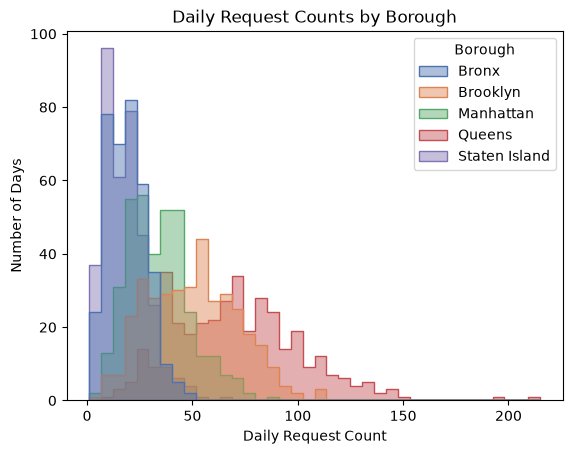

In [30]:
# Write your code here.
sns.histplot(data=daily_requests, x='request_count', hue='borough', element='step', hue_order=borough_order, multiple = 'layer', 
             alpha=0.45, palette = 'deep')

plt.gca().get_legend().set_title('Borough')
plt.title('Daily Request Counts by Borough')
plt.xlabel('Daily Request Count')
plt.ylabel('Number of Days')
plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram shows that the boroughs have different distributions of daily request counts. Some boroughs are concentrated around lower request counts like Bronx and Staten Island, while others are shifted toward higher counts like Brooklyn and Queens. The boroughs are more difficult to compare because the distributions overlap heavily which makes it harder to seperate which borough has more days at a particular request count.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


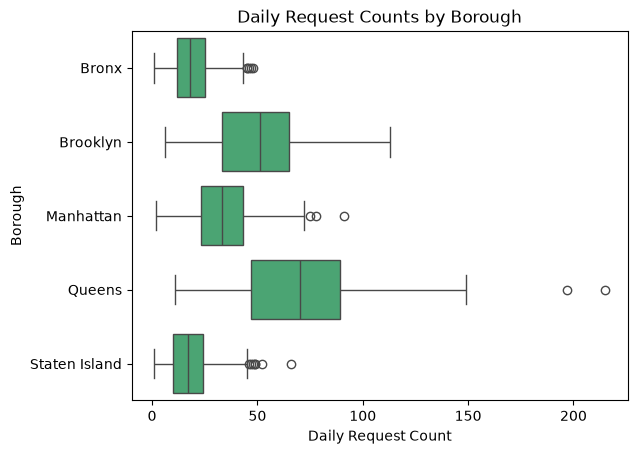

In [31]:
# Write your code here.
sns.boxplot(data=daily_requests, x='request_count', y='borough', order=borough_order, color='mediumseagreen')

plt.title('Daily Request Counts by Borough')
plt.xlabel('Daily Request Count')
plt.ylabel('Borough')
plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The box plot makes it easier to compare the boroughs’ median daily request counts and potential outliers. Since each borough has its own horizontal box plot, their typical request counts, and variability are easier to compare than in the overlapping histogram where the distributions can be difficult to distinguish.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


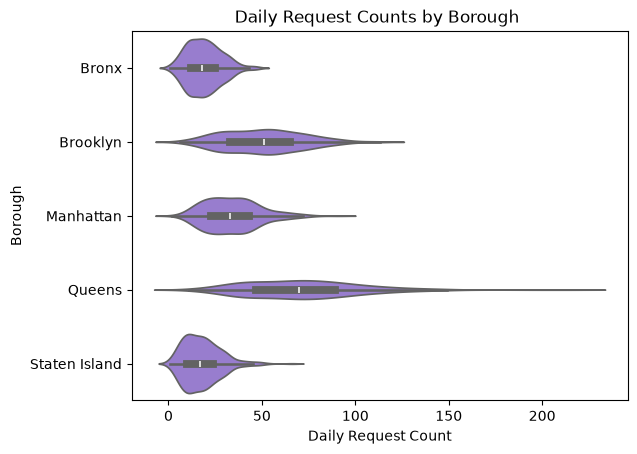

In [32]:
# Write your code here.
sns.violinplot(data=daily_requests, x='request_count', y='borough', order=borough_order, color='mediumpurple')

plt.title('Daily Request Counts by Borough ')
plt.ylabel('Borough')
plt.xlabel('Daily Request Count')
plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot adds more detail by showing the distribution and density of daily request counts for each borough. The wider or more stretched sections indicate where request counts are more concentrated and how much variability exists. Queens and Brooklyn appear to have greater variation, while the Bronx and Staten Island have narrower and more concentrated distributions. The small box plot inside each violin also helps show the median and spread.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot because we could clearly see the distribution comparisons for the daily request counts in each borough and each borough has its own plot, making it easier to compare the medians, ranges, variability, and possible outliers side by side. The histogram may have overlapping distributions and the violin plot can be hard to interpret. 


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: The 2025 data support the conclusion that Queens had the highest typical number of daily street-condition requests with the greatest mean daily request count of 71.18. Although Queens also showed considerable variability, its mean was still higher than the other boroughs indicating that Queens generally received more reported requests per day than the other boroughs.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: Because the data count reported service requests rather than actual street problems. Some boroughs may have more residents or people who are more likely to report issues, while others may have fewer residents or fewer reports. Therefore, a higher request count does not necessarily mean a borough has more street problems or performs worse.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the number of reported street-condition requests vary by day of the week in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use the original feature created_date to determine both the calendar date and the day of the week for each service request. Each row of my calculated DataFrame will represent one specific date, the corresponding day of the week, and the total number of reported street-condition requests recorded on that date.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [19]:
# Write your code here.
requests['date'] = requests['created_date'].dt.normalize()
requests['day_of_week'] = requests['date'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_daily_requests = requests.groupby(['date','day_of_week']).size().reset_index(name='request_count')

display(weekday_daily_requests)


,date,day_of_week,request_count
0,2025-01-01,Wednesday,189
1,2025-01-02,Thursday,240
2,2025-01-03,Friday,136
3,2025-01-04,Saturday,110
4,2025-01-05,Sunday,155
...,...,...,...
360,2025-12-27,Saturday,72
361,2025-12-28,Sunday,118
362,2025-12-29,Monday,200
363,2025-12-30,Tuesday,196


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: I created a date feature from created_date by removing the time component and created a day_of_week feature using the day name. I then grouped the records by each calendar date and its corresponding day of the week, counting the requests for each date. I saved the resulting DataFrame as weekday_daily_requests, where each row represents the total number of reported street condition requests for one specific date.



## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [23]:
# Write your code here.
display(weekday_daily_requests.isnull().sum())

display((weekday_daily_requests['request_count'] < 0).sum())

display(weekday_daily_requests['day_of_week'].unique())

display(weekday_daily_requests.groupby('day_of_week')['request_count'].describe().reindex(weekday_order))

date             0
day_of_week      0
request_count    0
dtype: int64

np.int64(0)

<ArrowStringArray>
['Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday']
Length: 7, dtype: str

,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Monday,52.0,226.384615,58.222748,96.0,194.75,217.0,258.00,408.0
Tuesday,52.0,240.750000,53.614775,101.0,208.50,243.0,274.25,362.0
Wednesday,53.0,236.886792,57.224477,104.0,194.00,234.0,274.00,426.0
Thursday,52.0,223.115385,56.400756,40.0,192.75,216.0,265.25,330.0
Friday,52.0,183.653846,55.178457,63.0,144.00,177.5,217.25,308.0
Saturday,52.0,111.519231,28.413260,60.0,91.75,110.0,128.25,178.0
Sunday,52.0,123.096154,29.658355,57.0,104.75,124.0,146.25,186.0


**What did your checks establish?**

Your answer: My checks established that there were no missing values or impossible negative request counts in the calculated DataFrame. All seven intended weekday groups were present: Monday through Sunday. The numerical summary also provided an overview of the daily request count distribution across the days of the week.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


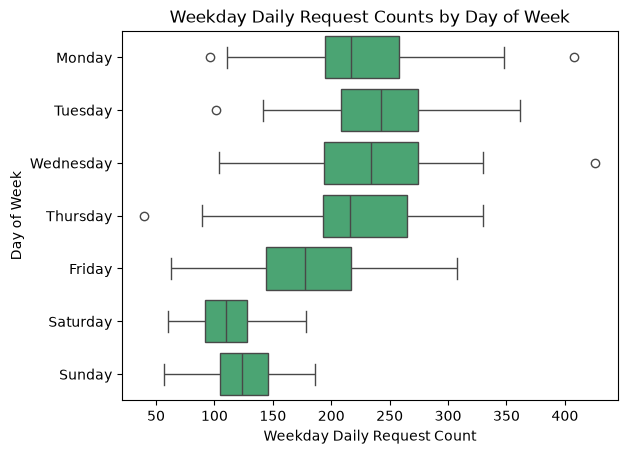

In [22]:
# Write your code here.

sns.boxplot(data=weekday_daily_requests, x='request_count', y='day_of_week', order=weekday_order, color='mediumseagreen')

plt.title('Weekday Daily Request Counts by Day of Week')
plt.xlabel('Weekday Daily Request Count')
plt.ylabel('Day of Week')
plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The strongest evidence is the position of each weekday’s box plot along the x-axis, especially the median lines. Mondays through Thursdays had the highest typical daily request counts with median values ranging from 216 to 243 requests. Friday had a lower median of 177.5 while Saturday and Sunday had the lowest typical daily request counts with medians of 110 and 124 requests respectively.



## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: The number of reported street-condition requests varied by day of the week, with the highest typical daily request counts occurring from Monday through Thursday. Friday had fewer requests, while Saturday and Sunday had the lowest typical daily request counts. This shows that street-condition reports were generally more frequent on weekdays than on weekends.



## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: One important limitation is that the data measure reported 311 service requests and not actual street quality/problems or government performance. Therefore, the results do not necessarily mean that street conditions were better or worse on particular days.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used ChatGPT to help me understand why my code for checking impossible values was incorrect. I initially wrote display((daily_requests['request_count < 0']).sum()), but I immediatelty saw that placing < 0 inside the brackets makes Python look for a column literally named request_count < 0. I accepted the suggestion to move the comparison outside the brackets and used the corrected code: display((daily_requests['request_count'] < 0).sum()).


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
